In [64]:
import pandas as pd

data = pd.read_csv("/content/SDSS Tabular Data.csv")

In [65]:
data

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.237650e+18,131.316413,51.539547,18.81777,17.47053,16.91508,16.68305,16.50570,1345,301,3,161,5.033450e+17,GALAXY,0.027583,447,51877,246
9996,1.237650e+18,131.306083,51.671341,18.27255,17.43849,17.07692,16.71661,16.69897,1345,301,3,162,5.033400e+17,GALAXY,0.117772,447,51877,228
9997,1.237650e+18,131.552562,51.666986,18.75818,17.77784,17.51872,17.43302,17.42048,1345,301,3,162,8.222620e+18,STAR,-0.000402,7303,57013,622
9998,1.237650e+18,131.477151,51.753068,18.88287,17.91068,17.53152,17.36284,17.13988,1345,301,3,163,5.033400e+17,GALAXY,0.014019,447,51877,229


In [66]:
unique = data['class'].value_counts()
print(unique)

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64


In [67]:
# After checking the columns with constant values, we saw objid and rerun column had only one value in all 10000 rows
print('-'*60)
print('Rerun Column has "301" value repeated for 10,000 times:-')
print('-'*60)
print(data['rerun'].value_counts())

print()

print('-'*70)
print('Objid column has the same thing, a value repeated for 10,000 times:-')
print('-'*70)
print(data['objid'].value_counts())

------------------------------------------------------------
Rerun Column has "301" value repeated for 10,000 times:-
------------------------------------------------------------
rerun
301    10000
Name: count, dtype: int64

----------------------------------------------------------------------
Objid column has the same thing, a value repeated for 10,000 times:-
----------------------------------------------------------------------
objid
1.237650e+18    10000
Name: count, dtype: int64


In [68]:
data.shape

(10000, 18)

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   objid      10000 non-null  float64
 1   ra         10000 non-null  float64
 2   dec        10000 non-null  float64
 3   u          10000 non-null  float64
 4   g          10000 non-null  float64
 5   r          10000 non-null  float64
 6   i          10000 non-null  float64
 7   z          10000 non-null  float64
 8   run        10000 non-null  int64  
 9   rerun      10000 non-null  int64  
 10  camcol     10000 non-null  int64  
 11  field      10000 non-null  int64  
 12  specobjid  10000 non-null  float64
 13  class      10000 non-null  object 
 14  redshift   10000 non-null  float64
 15  plate      10000 non-null  int64  
 16  mjd        10000 non-null  int64  
 17  fiberid    10000 non-null  int64  
dtypes: float64(10), int64(7), object(1)
memory usage: 1.4+ MB


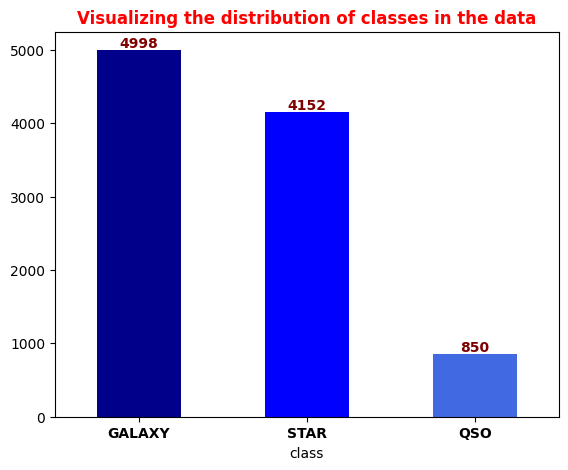

In [69]:
import matplotlib.pyplot as m
m.figure(figsize=(6.5,5))

ax = data['class'].value_counts().plot(kind = 'bar', color=['darkblue', 'blue','royalblue'])

ax.bar_label(ax.containers[0], color = 'maroon', weight='bold')

m.xticks(weight='bold', rotation=0)
m.title('Visualizing the distribution of classes in the data', color ='r', weight ='bold', fontsize=12)
m.show()

In [71]:
star_df = data[data['class']=='STAR']
qso_df =  data[data['class']=='QSO']
galaxy_df =   data[data['class']=='GALAXY']

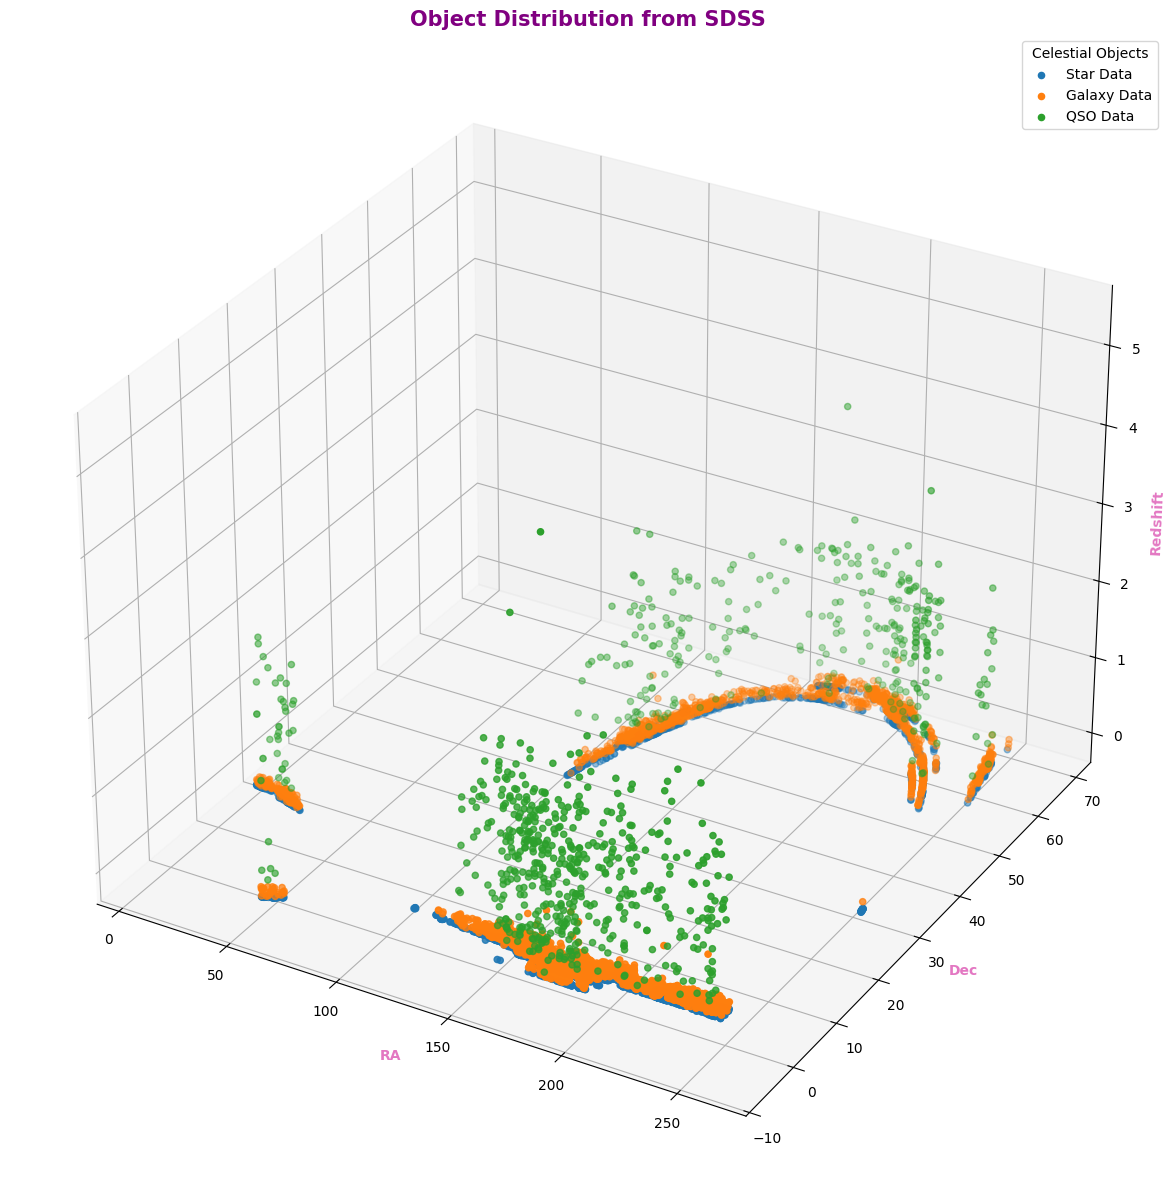

In [72]:
fig = m.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')


ax.scatter(star_df['ra'], star_df['dec'], star_df['redshift'], label='Star Data')
ax.scatter(galaxy_df['ra'], galaxy_df['dec'], galaxy_df['redshift'], label='Galaxy Data')
ax.scatter(qso_df['ra'], qso_df['dec'], qso_df['redshift'], label='QSO Data')


ax.set_xlabel('RA', color = 'tab:pink', weight='bold')
ax.set_ylabel('Dec', color = 'tab:pink', weight='bold')
ax.set_zlabel('Redshift', color = 'tab:pink', weight='bold')

ax.set_title('Object Distribution from SDSS', color='purple', weight='bold', fontsize=15)
m.legend(title='Celestial Objects', fontsize=10,)


m.savefig('Object Distribution from SDSS')
m.show()

In [82]:
X = data.drop(['objid', 'rerun', 'class'],axis=1)
y = data['class']

In [83]:
print(X.shape)
print(y.shape)

(10000, 15)
(10000,)


In [84]:
# Reshaping y into its colum vector format
y = y.values.reshape(-1, 1)

In [85]:
print(y.shape)

(10000, 1)


In [86]:
print(y)
print()
print(y.shape)

[['STAR']
 ['STAR']
 ['GALAXY']
 ...
 ['STAR']
 ['GALAXY']
 ['GALAXY']]

(10000, 1)


In [87]:
# Spliting the original data into training and testing (to evaluate the model performance later on)
from sklearn.model_selection import train_test_split

# Split 25% of the data randomly as test and keep 75% as train
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42, test_size=0.25)

In [88]:
# Check the shape --> Train must have 7500 rows and 15 cols, Val must have 2500 rows and 15 cols
print(f'X train shape:- {X_train.shape}\nX val shape:-{X_val.shape}')

X train shape:- (7500, 15)
X val shape:-(2500, 15)


In [89]:
'''
As we know y data is a string type data that our machines do not understand, so we need to convert it into numeric format.
Hence, we use one hot encoder for the same purpose here from sklearn
'''
# Call OneHotEncoder Class from sklearn
from sklearn.preprocessing import OneHotEncoder

# Create the object of one hot encoder of OneHotEncoder Class
enc = OneHotEncoder()

# Use fit_transform only on train data to take category and convert it into one hot encoded vector
y_train = enc.fit_transform(y_train)

# Convert output to numpy array
y_train = y_train.toarray()

In [90]:
print(y_train)

[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [91]:
print(y_train[0])

[0. 0. 1.]


In [103]:
enc.inverse_transform(y_train[0].reshape(1, -1))

array([['STAR']], dtype=object)

In [92]:
# Use only transform as enc object now know which one hot encoded vector is for GALAXY, STAR and QSO
y_val = enc.transform(y_val).toarray()       # Converting it to numpy array

In [93]:
# Check if it works well on y_test before moving forward
y_val[12]

array([0., 1., 0.])

In [94]:
# Importing Scaler from sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Creating the object of scaler
sc =  MinMaxScaler(feature_range=(0, 1)) # min scaled value = 0, max scaled value = 1

# fit will calculate min and max for each of the 15 features and transform will apply the formula explained above to transform it
X_train = sc.fit_transform(X_train)

In [95]:
# Check the data stored in sc after using fit on train data
print('Minimum values in all the features:-')
print(sc.data_min_)

print()

print('Similarly, Maximum values in all the features:-')
print(sc.data_max_)

print()

print('Check the total features used in scaler:-')
print(sc.n_features_in_)

Minimum values in all the features:-
[ 8.2351005e+00 -5.3826325e+00  1.4728250e+01  1.3205550e+01
  1.2444270e+01  1.2065440e+01  1.1757420e+01  3.0800000e+02
  1.0000000e+00  1.1000000e+01  2.9957800e+17 -4.1360780e-03
  2.6600000e+02  5.1578000e+04  1.0000000e+00]

Similarly, Maximum values in all the features:-
[2.60811189e+02 6.85422654e+01 1.95999000e+01 1.99189700e+01
 2.48020400e+01 2.43618100e+01 2.28269100e+01 1.41200000e+03
 6.00000000e+00 7.68000000e+02 9.46883000e+18 5.35385400e+00
 8.41000000e+03 5.74810000e+04 9.98000000e+02]

Check the total features used in scaler:-
15


In [96]:
# Check if min and max value after scaling train data is in between 0 to 1 or not
print('Train Range after Min Max Scaling:-')
print(X_train.min(), X_train.max())

Train Range after Min Max Scaling:-
0.0 1.0000000000000002


In [97]:
# Now just apply transform on the X_test
X_val = sc.transform(X_val)

In [98]:
# Now depending on the test data, the scaling might have value below 0 and above 1 as well. Let's check it
print('Test Range after Min Max Scaling:-')
print(X_test.min(), X_test.max())

Test Range after Min Max Scaling:-
ra           8.801675e+00
dec         -5.354572e+00
u            1.298897e+01
g            1.279955e+01
r            1.243160e+01
i            1.194721e+01
z            1.161041e+01
run          3.080000e+02
camcol       1.000000e+00
field        1.100000e+01
specobjid    2.996050e+17
redshift    -2.054598e-03
plate        2.660000e+02
mjd          5.160800e+04
fiberid      1.000000e+00
dtype: float64 ra           2.608844e+02
dec          6.853201e+01
u            1.959975e+01
g            1.968232e+01
r            2.480203e+01
i            2.817963e+01
z            2.283306e+01
run          1.412000e+03
camcol       6.000000e+00
field        7.680000e+02
specobjid    9.335010e+18
redshift     4.106183e+00
plate        8.291000e+03
mjd          5.740100e+04
fiberid      1.000000e+03
dtype: float64


In [77]:
pip install keras

In [99]:
# Importing Model, Layer and Tensorflow
from keras.models import Sequential
from keras.layers import Dense, Input

In [100]:
# Create the Model with Sequential Class
model = Sequential()

# Add different layers to the model
model.add(Input(shape=(15,)))                         # Input Layer --> 15 Neurons
model.add(Dense(64, activation='relu'))               # 1st Hidden Layer --> 64 Neurons
model.add(Dense(32, activation='relu'))               # Hidden Layer 2 --> 32 Neurons
model.add(Dense(16, activation='relu'))               # Hidden Layer 3 --> 16 Neurons
model.add(Dense(3, activation='softmax'))             # Output Layer --> 3 Neurons (star, galaxy, quasar)

# Print the Model Summary
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 64)                  │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,683 (14.39 KB)

 Trainable params: 3,683 (14.39 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
import keras
# Compile --> Optimizer, Loss Function, Evaluation Metrics
model.compile(optimizer = keras.optimizers.Adam(learning_rate=1e-3), # As Learning Rate is the hyperparameter, we can change it to see impact on training
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [102]:
# Train the model
history = model.fit(X_train,                          # Pass X_train data
                    y_train,                          # Pass y_train data
                    validation_data=(X_val, y_val),   # Validation Data
                    epochs=40,                        # Hyperparameter that can be tuned to achieve maximum performance
                    batch_size=32)                    # Set batch size

Epoch 1/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6671 - loss: 0.7978 - val_accuracy: 0.8428 - val_loss: 0.4730
Epoch 2/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8675 - loss: 0.3919 - val_accuracy: 0.8932 - val_loss: 0.3017
Epoch 3/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8925 - loss: 0.2945 - val_accuracy: 0.8988 - val_loss: 0.2634
Epoch 4/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9123 - loss: 0.2481 - val_accuracy: 0.9116 - val_loss: 0.2322
Epoch 5/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9221 - loss: 0.2228 - val_accuracy: 0.9128 - val_loss: 0.2162
Epoch 6/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9304 - loss: 0.1964 - val_accuracy: 0.9356 - val_loss: 0.1912
Epoch 7/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9377 - loss: 0.1825 - val_accuracy: 0.9376 - val_loss: 0.1861
Epoch 8/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9442 - loss: 0.1623 - val_accuracy: 0.

In [54]:
history

In [55]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

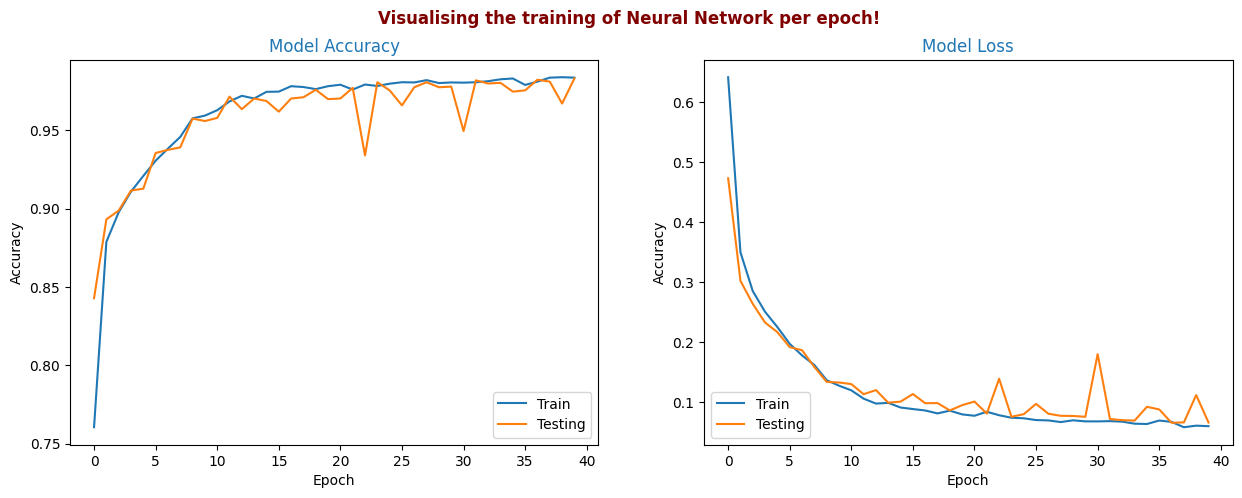

In [103]:
m.figure(figsize=(15,5))
m.suptitle("Visualising the training of Neural Network per epoch! \n", weight='bold', color = 'maroon')

m.subplot(1, 2, 1)
m.plot(history.history['accuracy'], label='Train')
m.plot(history.history['val_accuracy'], label='Testing')
m.title('Model Accuracy', color='tab:blue')
m.xlabel('Epoch')
m.ylabel('Accuracy')
m.legend(loc='lower right')

m.subplot(1, 2, 2)
m.plot(history.history['loss'], label='Train')
m.plot(history.history['val_loss'], label='Testing')
m.title('Model Loss', color='tab:blue')
m.xlabel('Epoch')
m.ylabel('Accuracy')
m.legend(loc='lower left')

m.show()

In [104]:
y_predict = model.predict(X_val)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [105]:
y_predict

array([[9.9886405e-01, 1.1354462e-03, 4.0116419e-07],
       [3.6033438e-04, 9.9963963e-01, 0.0000000e+00],
       [9.7393960e-01, 1.6223288e-03, 2.4438042e-02],
       ...,
       [9.9963975e-01, 3.5783643e-04, 2.3695532e-06],
       [1.9712582e-04, 9.9980289e-01, 0.0000000e+00],
       [9.9627364e-01, 3.7260524e-03, 4.0109310e-07]], dtype=float32)

In [106]:
y_val_class = enc.inverse_transform(y_val)
y_predict_class = enc.inverse_transform(y_predict)

In [107]:
print('Actual values:-')
print(y_val_class)
print()
print('Predicted values:-')
print(y_predict_class)

Actual values:-
[['GALAXY']
 ['QSO']
 ['GALAXY']
 ...
 ['GALAXY']
 ['QSO']
 ['GALAXY']]

Predicted values:-
[['GALAXY']
 ['QSO']
 ['GALAXY']
 ...
 ['GALAXY']
 ['QSO']
 ['GALAXY']]


In [109]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val_class, y_predict_class)

In [110]:
cm

array([[1224,    5,   17],
       [   8,  234,    0],
       [  11,    1, 1000]])

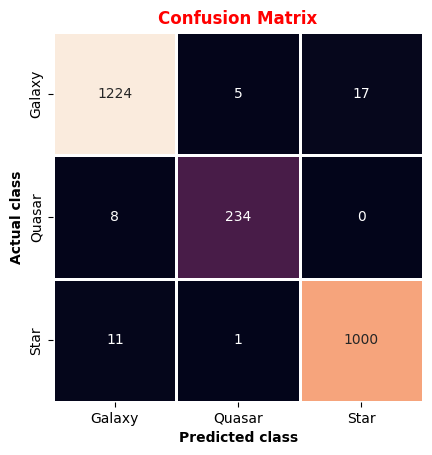

In [118]:
import seaborn as sns
labels = ["Galaxy",'Quasar','Star']

sns.heatmap(cm, xticklabels = labels, yticklabels = labels, annot=True, fmt='d', cbar=False, square=True, linewidth =2)

m.title('Confusion Matrix', weight='bold', color='red')
m.xlabel("Predicted class", weight='bold')
m.ylabel("Actual class", weight='bold')

m.show()


In [119]:
model.save('Dev_1st_NN_Project.h5')

In [120]:
# Save the encoder and scaler as joblib
from joblib import dump
dump(enc, 'encoder_W9S3.joblib')
dump(sc, 'scaler_W9S3.joblib')

['scaler_W9S3.joblib']

In [121]:
# Create the scaler for testing using the saved file
from joblib import load
scaler_test = load('scaler_W9S3.joblib')

In [124]:
scaler_test.data_min_

array([ 8.2351005e+00, -5.3826325e+00,  1.4728250e+01,  1.3205550e+01,
        1.2444270e+01,  1.2065440e+01,  1.1757420e+01,  3.0800000e+02,
        1.0000000e+00,  1.1000000e+01,  2.9957800e+17, -4.1360780e-03,
        2.6600000e+02,  5.1578000e+04,  1.0000000e+00])

In [125]:
sc.min_

array([-3.26044344e-02,  7.28121736e-02, -3.02325701e+00, -1.96703766e+00,
       -1.00699964e+00, -9.81219661e-01, -1.06214649e+00, -2.78985507e-01,
       -2.00000000e-01, -1.45310436e-02, -3.26720217e-02,  7.71945812e-04,
       -3.26620825e-02, -8.73759106e+00, -1.00300903e-03])

In [126]:
scaler_test.min_ #both are same, proving the loaded file is working as expected !!!

array([-3.26044344e-02,  7.28121736e-02, -3.02325701e+00, -1.96703766e+00,
       -1.00699964e+00, -9.81219661e-01, -1.06214649e+00, -2.78985507e-01,
       -2.00000000e-01, -1.45310436e-02, -3.26720217e-02,  7.71945812e-04,
       -3.26620825e-02, -8.73759106e+00, -1.00300903e-03])

In [127]:
# Create the scaler for testing using the saved file
from joblib import load
enc_test = load('encoder_W9S3.joblib')

In [128]:
enc_test.inverse_transform(y_predict)

array([['GALAXY'],
       ['QSO'],
       ['GALAXY'],
       ...,
       ['GALAXY'],
       ['QSO'],
       ['GALAXY']], dtype=object)

In [129]:
enc.inverse_transform(y_predict) #both are same, proving the loaded file is working as expected !!!

array([['GALAXY'],
       ['QSO'],
       ['GALAXY'],
       ...,
       ['GALAXY'],
       ['QSO'],
       ['GALAXY']], dtype=object)